In [9]:
import joblib
import pandas as pd
model_lr = joblib.load('../models/logistic_regression_baseline.pkl')
model_rf = joblib.load('../models/random_forest.pkl')
model_xgb = joblib.load('../models/xgboost_model.pkl')
X_test = pd.read_csv('../data/X_test.csv')
Y_test = pd.read_csv('../data/y_test.csv').values.ravel()

In [4]:
from sklearn.preprocessing import StandardScaler
X_train = pd.read_csv('../data/X_train.csv')

scaler = StandardScaler()
scaler.fit(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
Y_pred_lr = model_lr.predict(X_test_scaled)
Y_proba_lr = model_lr.predict_proba(X_test_scaled)[:, 1]


In [6]:
Y_pred_rf = model_rf.predict(X_test)
Y_proba_rf = model_rf.predict_proba(X_test)[:, 1]

In [7]:
Y_pred_xgb = model_xgb.predict(X_test)
Y_proba_xgb = model_xgb.predict_proba(X_test)[:, 1]

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def get_metrics(name, Y_true, Y_pred, Y_proba):
    return {
        'Model': name,
        'Accuracy': accuracy_score(Y_true, Y_pred),
        'Precision': precision_score(Y_true, Y_pred),
        'Recall': recall_score(Y_true, Y_pred),
        'F1': f1_score(Y_true, Y_pred),
        'ROC-AUC': roc_auc_score(Y_true, Y_proba)
    }

import pandas as pd
results = pd.DataFrame([
    get_metrics('Logistic Regression', Y_test, Y_pred_lr, Y_proba_lr),
    get_metrics('Random Forest', Y_test, Y_pred_rf, Y_proba_rf),
    get_metrics('XGBoost', Y_test, Y_pred_xgb, Y_proba_xgb)
])
print(results)

                 Model  Accuracy  Precision    Recall        F1   ROC-AUC
0  Logistic Regression  0.740241   0.506897  0.786096  0.616352  0.841401
1        Random Forest  0.757275   0.529412  0.770053  0.627451  0.840002
2              XGBoost  0.755855   0.528195  0.751337  0.620309  0.831192


Selected logistic regression as the final model because it achieves the highest recall (.78) and highest roc-auc(.841) meaning it catches the most actual churners — directly aligned with the business goal of minimizing missed at-risk customers, even at some cost to precision.
I evaluated three models and selected Logistic Regression over more complex alternatives because it achieved the highest recall — which mattered most for this business case — rather than defaulting to the most sophisticated option

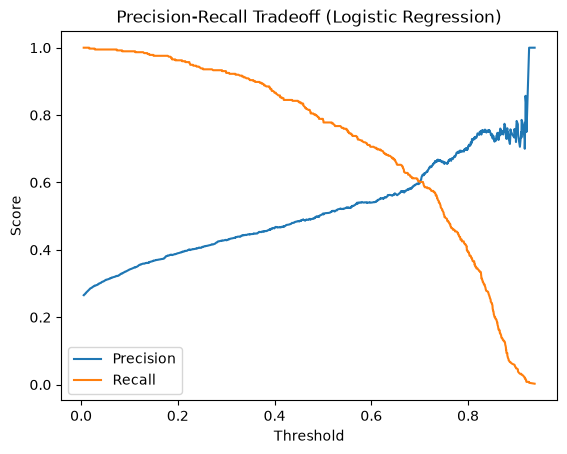

In [11]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precisions, recalls, thresholds = precision_recall_curve(Y_test, Y_proba_lr)

plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Tradeoff (Logistic Regression)')
plt.legend()
plt.show()

In [12]:
for t in [0.3, 0.4, 0.5]:
    Y_pred_custom = (Y_proba_lr >= t).astype(int)
    from sklearn.metrics import precision_score, recall_score, f1_score
    print(f"Threshold {t}: Precision={precision_score(Y_test, Y_pred_custom):.3f}, "
          f"Recall={recall_score(Y_test, Y_pred_custom):.3f}, "
          f"F1={f1_score(Y_test, Y_pred_custom):.3f}")

Threshold 0.3: Precision=0.429, Recall=0.925, F1=0.586
Threshold 0.4: Precision=0.465, Recall=0.866, F1=0.605
Threshold 0.5: Precision=0.507, Recall=0.786, F1=0.616


In [13]:
final_model_package = {
    'model': model_lr,
    'scaler': scaler,   # needed since Logistic Regression requires scaled input
    'threshold': 0.3
}

import joblib
joblib.dump(final_model_package, '../models/final_churn_model.pkl')

['../models/final_churn_model.pkl']

In [14]:
loaded = joblib.load('../models/final_churn_model.pkl')
print(loaded['model'])
print(loaded['scaler'])
print(loaded['threshold'])

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
StandardScaler()
0.3
